# Vizualicaion de Datos con matplotlib y seaborn
### Curso: AI & Machine Learning Dataset: Titanic

**Estudiante:** Gerard Almanzar
**Curso:** AI & Machine Learning
**Dataset:** ecommerce_devoluciones_sucio.csv

### Objetivo
visualizar los datos del dataset.


# Módulo 1. Importación de Librerías

En esta sección se importan las librerías necesarias para el análisis y limpieza de datos.

In [6]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.options.future.infer_string = False

# Modulo 2. Carga y Exploración Inicial

Se carga el dataset y se realiza una inspección inicial.

In [16]:
#crear carpetas para las graficas autmomaticamente si no existe

os.makedirs('graficas', exist_ok=True)

df = pd.read_csv('empleados_empresa.csv')

#Exploracion inicial

print("Forma del dataset: ", df.shape)
print("\nColumnas: ")
print(list(df.columns))
print("\nTipos de datos:")
print(df.dtypes)

Forma del dataset:  (200, 12)

Columnas: 
['EmpleadoID', 'Genero', 'Departamento', 'RolTrabajo', 'NivelEducacion', 'Edad', 'SalarioMensual', 'AnosEnEmpresa', 'ViajaNegocio', 'Renuncia', 'GrupoEdad', 'ViajaFrecuente']

Tipos de datos:
EmpleadoID          int64
Genero             object
Departamento       object
RolTrabajo         object
NivelEducacion     object
Edad              float64
SalarioMensual    float64
AnosEnEmpresa       int64
ViajaNegocio       object
Renuncia            int64
GrupoEdad          object
ViajaFrecuente      int64
dtype: object


# Limpieza, Normalización y tipo de datos





In [31]:
#Vamos a cambiar los tipos de datos que se requieran antes de poder visualizar la informacion.

#fix: GrupoEdad pierde el tipo y el orden al guardarse en CSV
#pd.gategorical con ordered=True recupera ambos a la vez

orden_edad = ['Joven', 'Adulto Joven', 'Adulto', 'Senior']
df['GrupoEdad'] = pd.Categorical(df['GrupoEdad'], categories=orden_edad, ordered=True)

print("GrupoEdad ahora: ", df['GrupoEdad'].dtype)
print(df['GrupoEdad'].value_counts().sort_index())


GrupoEdad ahora:  category
GrupoEdad
Joven           59
Adulto Joven    74
Adulto          52
Senior          15
Name: count, dtype: int64


# Visualizacion de datos.




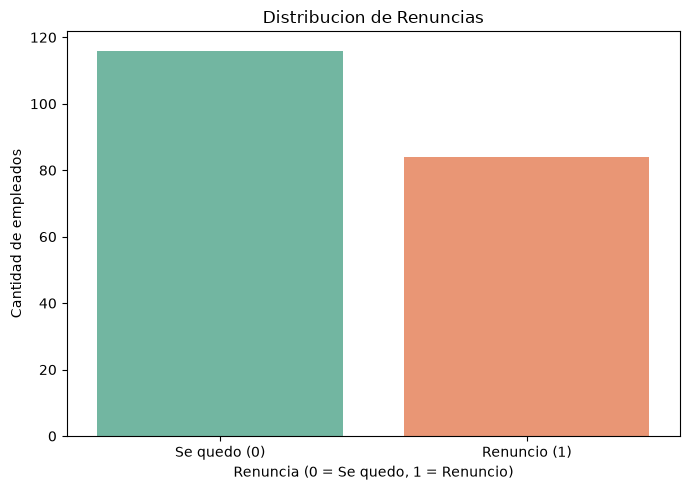

Total de
Renuncia
0    116
1     84
Name: count, dtype: int64

Porcentaje de
Renuncia
0    58.0
1    42.0
Name: count, dtype: float64


In [20]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='Renuncia', hue='Renuncia', palette='Set2', legend=False)
plt.title('Distribucion de Renuncias')
plt.xlabel('Renuncia (0 = Se quedo, 1 = Renuncio)')
plt.ylabel('Cantidad de empleados')
plt.xticks([0,1], ['Se quedo (0)', 'Renuncio (1)'])
plt.tight_layout()
plt.savefig('graficas/01_renuncia.png')
plt.show()

print('Total de')
print(df['Renuncia'].value_counts())
print('\nPorcentaje de')
print((df['Renuncia'].value_counts() / len(df) * 100 ).round(2))

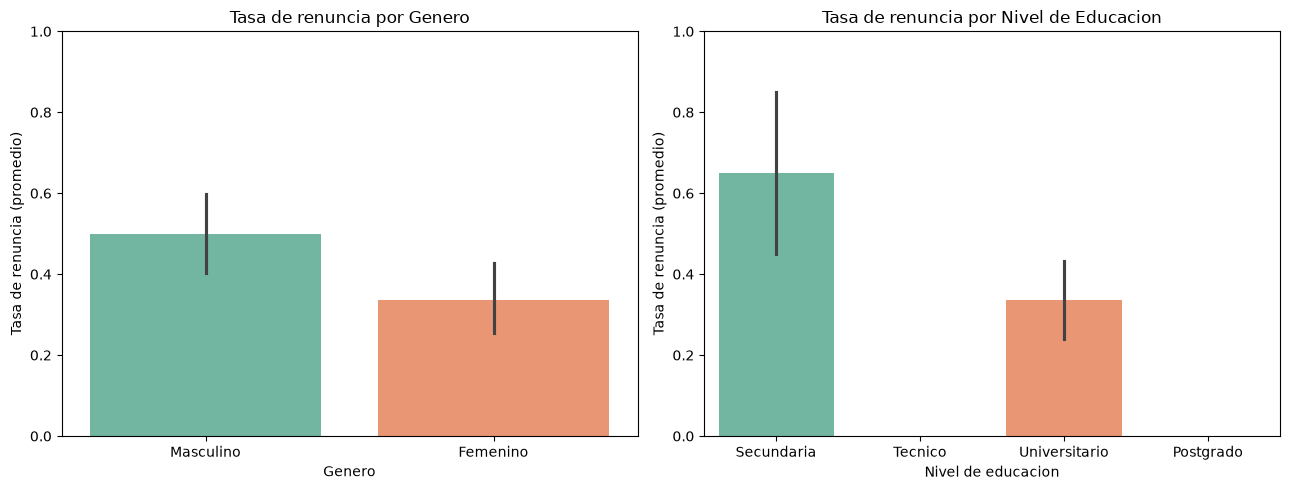

Renuncia por Genero
           mean  count
Genero                
Femenino   0.34     98
Masculino  0.50    102

Renuncia por NivelEducacion: 
                mean  count
NivelEducacion             
Posgrado        0.30     40
Secundaria      0.65     20
Técnico         0.54     57
Universitario   0.34     83


In [23]:
#Renuncia por Genero y nivel de Educacion - barplot doble

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

#Trabajando con la grafica a la izquierda
sns.barplot(data=df, x='Genero', y='Renuncia', hue='Genero', palette='Set2', legend=False, ax=axes[0])
axes[0].set_title('Tasa de renuncia por Genero')
axes[0].set_xlabel('Genero')
axes[0].set_ylabel('Tasa de renuncia (promedio)')
axes[0].set_ylim(0,1)

#Trabajando con la grafica a la derecha

orden_edu = ['Secundaria', 'Tecnico', 'Universitario', 'Postgrado']
sns.barplot(data=df, x='NivelEducacion', y='Renuncia', hue='NivelEducacion', palette='Set2', order=orden_edu, legend=False, ax=axes[1])
axes[1].set_title('Tasa de renuncia por Nivel de Educacion')
axes[1].set_xlabel('Nivel de educacion')
axes[1].set_ylabel('Tasa de renuncia (promedio)')
axes[1].set_ylim(0,1)

plt.tight_layout()
plt.savefig('graficas/02_genero_educacion.png')
plt.show()

#algunos prints para reforzamiento de la informacion visualizada
print('Renuncia por Genero')
print(df.groupby('Genero')['Renuncia'].agg(['mean', 'count']).round(2))
print()
print('Renuncia por NivelEducacion: ')
print(df.groupby('NivelEducacion')['Renuncia'].agg(['mean', 'count']).round(2))




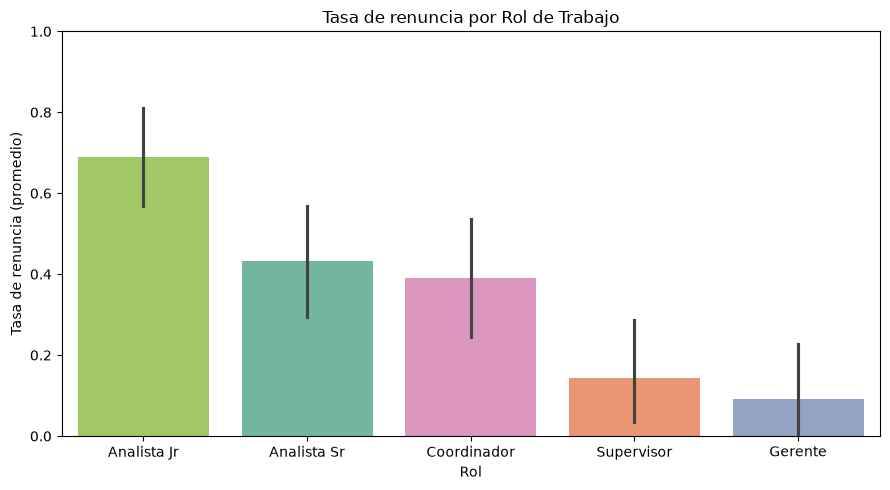

Renuncia por Rol de Trabajo
             mean  count
RolTrabajo              
Analista Jr  0.69     58
Analista Sr  0.43     51
Coordinador  0.39     41
Supervisor   0.14     28
Gerente      0.09     22


In [29]:
#renuncia por Rol de Trabajo - barplot ordenado
#ordenar de mayor a menor la tase de renuncia
#sort_values(ascending=False) ordena de mayor a menor.
#index extrae solo los nombres en ese orden (sin los valores numericos)

orden_rol = df.groupby('RolTrabajo')['Renuncia'].mean().sort_values(ascending=False).index

plt.figure(figsize=(9, 5))
sns.barplot(data=df, x='RolTrabajo', order=orden_rol, y='Renuncia', hue='RolTrabajo', palette='Set2', legend=False)
plt.title('Tasa de renuncia por Rol de Trabajo')
plt.xlabel('Rol')
plt.ylabel('Tasa de renuncia (promedio)')
plt.ylim(0,1)
plt.tight_layout()
plt.savefig('graficas/03_roltrabajo.png')
plt.show()

#haremos unos prints para el reforzamiento de la informacion
print('Renuncia por Rol de Trabajo')
print(df.groupby('RolTrabajo')['Renuncia'].agg(['mean', 'count']).round(2).sort_values('mean', ascending=False))


Renuncia  por Grupoedad (en orden logico de dedad): 
              mean  count
GrupoEdad                
Adulto        0.38     52
Adulto Joven  0.43     74
Joven         0.51     59
Senior        0.13     15


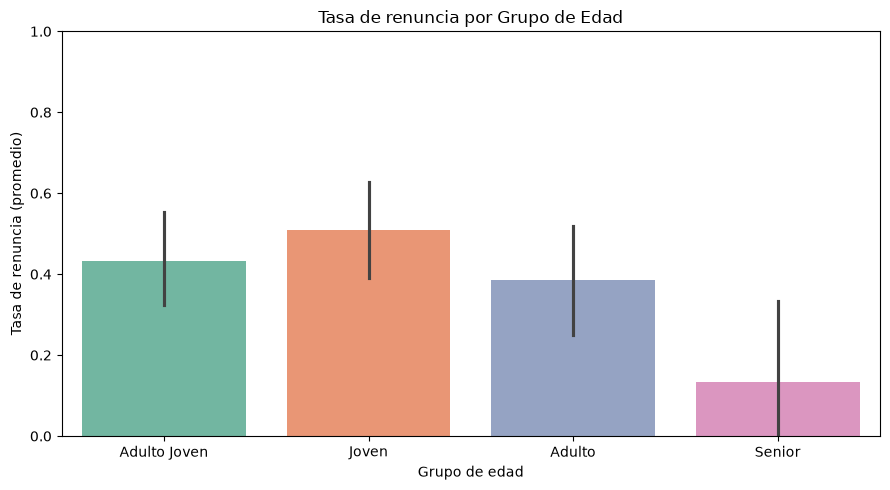

In [30]:
#Renuncia por Grupo de edad - categoria ordenada
#GrupoEdad ya tiene el fix aplicado desde el paso 0

plt.figure(figsize=(9, 5))
sns.barplot(data=df, x='GrupoEdad', y='Renuncia', hue='GrupoEdad', palette='Set2', legend=False)
plt.title('Tasa de renuncia por Grupo de Edad')
plt.xlabel('Grupo de edad')
plt.ylabel('Tasa de renuncia (promedio)')
plt.ylim(0,1)
plt.tight_layout()
plt.savefig('graficas/04_grupoedad.png')

#haremos varios prints para reforzar la informacion dada en la visualizacion.
#observed=True: solo muestra las categorías que tienen datos reales en este dataset
print('Renuncia  por Grupoedad (en orden logico de dedad): ')
print(df.groupby('GrupoEdad', observed=True)['Renuncia'].agg(['mean', 'count']).round(2))


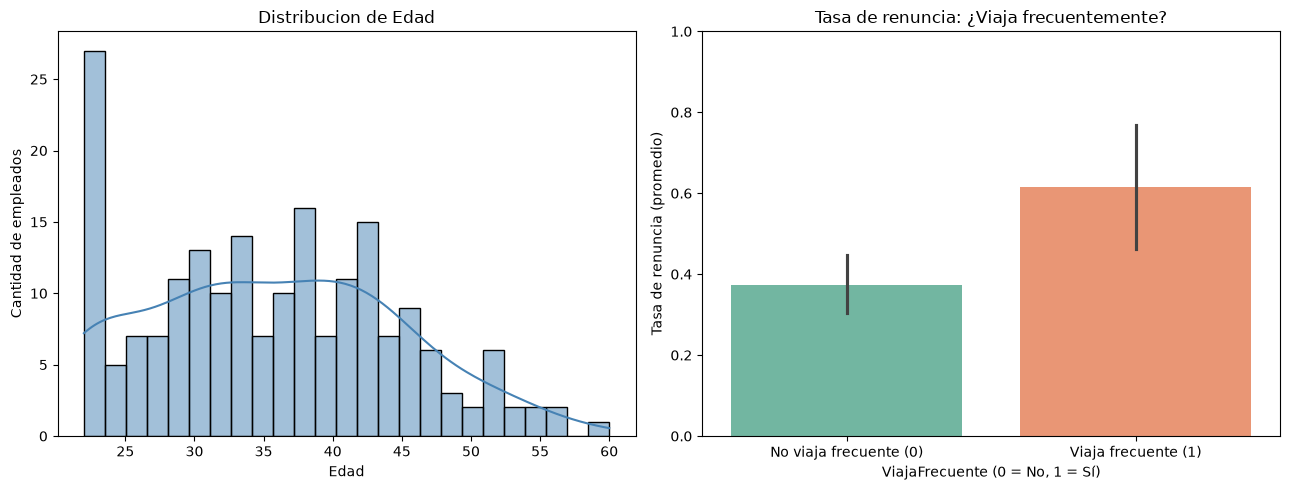

Estadisticas de Edad:
count    200.00
mean      35.60
std        9.13
min       22.00
25%       28.40
50%       35.60
75%       42.40
max       60.00
Name: Edad, dtype: float64

Renuncia por ViajaFrecuente: 
                mean  count
ViajaFrecuente             
0               0.37    161
1               0.62     39


In [33]:
#Distribucion de Edad + Renuncia por Viaje Frecuente

fig, axes = plt.subplots(1,2, figsize=(13,5))

#Trabajando con la parte de la izquierda: distribucion de edad (histograma con KDE)
#kde=True agrega la curva suavizada qe muestra la forma de la distribucion.
sns.histplot(data=df, x='Edad', bins=25, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Distribucion de Edad')
axes[0].set_xlabel('Edad')
axes[0].set_ylabel('Cantidad de empleados')

#derecha: renuncia por ViajeFrecuente

sns.barplot(data=df, x='ViajaFrecuente', y='Renuncia', hue='ViajaFrecuente', palette='Set2', legend=False, ax=axes[1])
axes[1].set_title('Tasa de renuncia: ¿Viaja frecuentemente?')
axes[1].set_xlabel('ViajaFrecuente (0 = No, 1 = Sí)')
axes[1].set_ylabel('Tasa de renuncia (promedio)')
axes[1].set_ylim(0, 1)
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['No viaja frecuente (0)', 'Viaja frecuente (1)'])


plt.tight_layout()
plt.savefig('graficas/05_edad_viaje.png')
plt.show()

#Prints para reforzamiento de informacion
print('Estadisticas de Edad:')
print(df['Edad'].describe().round(2))
print()
print('Renuncia por ViajaFrecuente: ')
print(df.groupby('ViajaFrecuente')['Renuncia'].agg(['mean', 'count']).round(2))